In [1]:
from IROS._pipeline_support import _handle_dirpaths

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.optim import model_sky

import darksun as ds
from darksun.data import Log

In [2]:
import matplotlib as mpl

RCPARAMS = {
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
PCAM = {
    "sourcename_fs": 6,
    "title_fs": 12,
    "title_pad": 8,
    "txt_fw": "bold",
    "txt_color": "black",
}
mpl.rcParams.update(RCPARAMS)


def _handle_subplots(nplots, spacing=0.27):
    """Creates and configures subplots."""
    size = 6
    fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
    fig, axes = plt.subplots(1, nplots, figsize=fig_size)
    fig.tight_layout()
    fig.subplots_adjust(wspace=spacing * 5 / size)
    return fig, (axes if nplots > 1 else [axes])

def _set_labels(ax, xlabel, ylabel, title):
    """Configures labels and titles."""
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

def _set_ticks(ax):
    """Configures grid and tick properties."""
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.ticklabel_format(scilimits=(-3, 4))

def plot_sequence(
    input_sequence: list,
    title: list[str],
    label: list = None,
    x: list = None,
    xlabel: list[str] = None,
    ylabel: list[str] = None,
    color: list[tuple[str, str]] = None,
    style: list[str] = None,
    offsetx: list[tuple[float, float]] = None,
    offsety: list[tuple[float, float]] = None,
    save_to: str = None,
) -> None:

    nplots = len(input_sequence)
    x = x or [None] * nplots
    label = label or [None] * nplots
    xlabel = xlabel or [None] * nplots
    ylabel = ylabel or [None] * nplots
    color = color or [('OrangeRed', 'r')] * nplots
    style = style or ['bar'] * nplots
    offsetx = offsetx or [(None, None)] * nplots
    offsety = offsety or [(None, None)] * nplots

    fig, axes = _handle_subplots(nplots)
    for i, ax in enumerate(axes):
        x_values = x[i] if x[i] is not None else np.arange(len(input_sequence[i]))

        if isinstance(input_sequence[i], tuple):
            for idx in range(len(input_sequence[i])):
                fcolor, ecolor = color[i][idx]
                ax.plot(x_values, input_sequence[i][idx], c=ecolor, alpha=0.75, label=label[i][idx])
        else:
            fcolor, ecolor = color[i]
            if style[i] == 'scatter':
                ax.plot(x_values, input_sequence[i], c=fcolor, alpha=0.75)
            else:
                ax.bar(x_values, input_sequence[i], width=1, facecolor=fcolor,
                       edgecolor=ecolor, linewidth=1, alpha=0.70)

        ax.set_xlim(offsetx[i][0], offsetx[i][1])
        ax.set_ylim(offsety[i][0], offsety[i][1])
        _set_labels(ax, xlabel[i], ylabel[i], title[i])
        _set_ticks(ax)
        if label[i] is not None: ax.legend(loc='best')
    
    if save_to is not None: plt.savefig(save_to)
    plt.show()

def enhance_slices(
    sky: list[np.array],
    label: list,
    pos: tuple[int],
    crp: tuple[int] = (40, 40),
    source: str = None,
    cameraID: str = None,
    offsety_first: list[tuple[float, float]] = None,
    offsety_second: list[tuple[float, float]] = None,
    save_to_first: str = None,
    save_to_second: str = None,
) -> None:
    
    sky_A, sky_B = sky
    cropped_A = ds.crop(sky_A, pos, crp, False)
    xslice_A, yslice_A = cropped_A[crp[0], :], cropped_A[:, crp[1]]
    cropped_B = ds.crop(sky_B, pos, crp, False)
    xslice_B, yslice_B = cropped_B[crp[0], :], cropped_B[:, crp[1]]

    plot_sequence(
        input_sequence=[(xslice_A, xslice_B), (yslice_A, yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        label=label,
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        color=[(('white', 'r'), ('white', 'DodgerBlue'))] * 2,
        offsety=offsety_first,
        save_to=save_to_first,
    )
    plot_sequence(
        input_sequence=[(xslice_A - xslice_B), (yslice_A - yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice Residues - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        style=["scatter"] * 2,
        offsety=offsety_second,
        save_to=save_to_second,
    )

def image_plot(
    arr: NDArray,
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    cbarlabel: str = None,
    figsize: tuple[int | float] = (6, 6),
    dpi: int = 100,
    cbarscinot: bool = False,
    cbarloc: str = "right",
    **kwargs,
) -> None:
    """
    Plot the input 2D array.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.tight_layout()
    fig.dpi = dpi

    img = ax.imshow(arr, origin='lower', **kwargs)
    cbar = fig.colorbar(img, ax=ax, location=cbarloc, shrink=0.75, pad=0.05)
    cbar.ax.tick_params(labelsize=11)
    if cbarlabel: cbar.set_label(cbarlabel, fontsize=12, fontweight='bold')
    if cbarscinot: cbar.formatter.set_powerlimits((-3, 3))

    ax.set_title(title, fontsize=14, pad=8, fontweight='bold')
    ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    plt.show()

def plot_IROS_efficiency(
    log: Log,
    true_sky: NDArray,
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> None:
    """
    
    """
    true_sky = true_sky.copy()
    true_sky_sub = true_sky.copy()
    UPX, UPY = camera.upscale_f

    for source, sx, sy, f, x, y in zip(
        log.log["ID"],
        log.log["shift_x"],
        log.log["shift_y"],
        log.log["fluence"],
        log.log["x"],
        log.log["y"],
    ):
        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        _crp_true = true_sky[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _crp_true_sub = true_sky_sub[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _crp_modeled = modeled[y - crp[0] : y + crp[0] + 1, x - crp[1] : x + crp[1] + 1]
        _l = max(
            #np.abs(_crp_true - _crp_modeled)[crp[0], :].max(),
            np.abs(_crp_true_sub - _crp_modeled)[crp[0], :].max(),
            #np.abs(_crp_true - _crp_modeled)[:, crp[1]].max(),
            np.abs(_crp_true_sub - _crp_modeled)[:, crp[1]].max(),
        )
        COUNTS_LIMS = (
            min(_crp_true.min(), _crp_modeled.min()) - f // 20,
            max(_crp_true.max(), _crp_modeled.max()) + f // 20,
        )
        RES_LIMS = (-_l, _l)
        POS = (y, x)

        # plot true sky and source model
        #enhance_slices(
        #    sky=[true_sky, modeled],
        #    label=[("original", "IROS")] * 2,
        #    pos=POS,
        #    crp=crp,
        #    source=source,
        #    cameraID=cameraID,
        #    offsety_first=[COUNTS_LIMS] * 2,
        #    offsety_second=[RES_LIMS] * 2,
        #    #save_to_first=save_path + "../models.png",
        #    #save_to_second=save_path + "../res.png",
        #)
        enhance_slices(
            sky=[true_sky_sub, modeled],
            label=[("true (+IROS)", "IROS")] * 2,
            pos=POS,
            crp=crp,
            source=source,
            cameraID=log.name,
            offsety_first=[COUNTS_LIMS] * 2,
            offsety_second=[RES_LIMS] * 2,
            #save_to_first=save_path + "../models.png",
            #save_to_second=save_path + "../res.png",
        )

        # plot heatmaps
        CUT = (
            int(camera.specs["slit_deltay"] * UPY / camera.specs["mask_deltay"]),
            int(camera.specs["slit_deltax"] * UPX / camera.specs["mask_deltax"]),
        )
        DPI = 100
        SCINOT = True

        #true_cropped = ds.crop(
        #    image=true_sky,
        #    pos=POS,
        #    crp=CUT,
        #    strict=False,
        #)
        true_sub_cropped = ds.crop(
            image=true_sky_sub,
            pos=POS,
            crp=CUT,
            strict=False,
        )
        modeled_cropped = ds.crop(
            image=modeled,
            pos=POS,
            crp=CUT,
            strict=False,
        )

        f_upy, f_upx = 2, 5
        #image_plot(
        #    arr=upscale(true_cropped - modeled_cropped, f_upy, f_upx) * np.prod((f_upy, f_upx)),
        #    title="Original - IROS Res.",
        #    #xlabel="x",
        #    #ylabel="y",
        #    cbarlabel="counts",
        #    cmap="bwr",
        #    vmin=RES_LIMS[0],
        #    vmax=RES_LIMS[1],
        #    extent=(-CUT[1] * f_upx, CUT[1] * f_upx, -CUT[0] * f_upy, CUT[0] * f_upy),
        #    dpi=DPI,
        #    cbarscinot=SCINOT,
        #)
        image_plot(
            arr=ds.upscale(true_sub_cropped - modeled_cropped, f_upy, f_upx) * np.prod((f_upy, f_upx)),
            title="True (+IROS) - IROS Res.",
            #xlabel="x",
            #ylabel="y",
            cbarlabel="counts",
            cmap="bwr",
            vmin=RES_LIMS[0],
            vmax=RES_LIMS[1],
            extent=(-CUT[1] * f_upx, CUT[1] * f_upx, -CUT[0] * f_upy, CUT[0] * f_upy),
            dpi=DPI,
            cbarscinot=SCINOT,
        )

        # remove source from true
        true_sky_sub -= modeled

In [3]:
from typing import NamedTuple

from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import equatorial2shift, shift2angle

from darksun.data import Log, DataLoader, CatalogueLoader


class CoordAngular(NamedTuple):
    """
    Local coded-mask camera angular coordinates.

    Args:
        theta_x (float): angular coord along x-axis [deg]
        theta_y (float): angular coord along y-axis [deg]
    """

    theta_x: float
    theta_y: float


def extract_catalogue_equatorial_coords(
    catalogue: CatalogueLoader
) -> tuple[tuple[str, CoordEquatorial]]:
    """
    
    """
    sources = catalogue.DLdata['ID']
    ras = catalogue.DLdata['RA']
    decs = catalogue.DLdata['DEC']
    return tuple(
        (name, CoordEquatorial(ra, dec)) for name, ra, dec in zip(sources, ras, decs)
    )


def extract_catalogue_angular_coords(
    log: Log,
    camera: CodedMaskCamera,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> tuple[tuple[str, CoordAngular]]:
    """
    
    """
    sources, thetas_x, thetas_y = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetas_x.append(shift2angle(camera, sx))
            thetas_y.append(shift2angle(camera, sy))
        else:
            print(f'Source {s_id} not in catalogue...')
            sources.append(s_id)
            thetas_x.append(-1)
            thetas_y.append(-1)
            continue
    return tuple(
        (name, CoordAngular(tx, ty)) for name, tx, ty in zip(sources, thetas_x, thetas_y)
    )


def extract_sources_fluences_from_sky(
    log: Log,
    true_sky: NDArray,
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """
    """
    true_ = true_sky.copy()
    res = []

    for sx, sy, f, x, y in zip(
        log.log["shift_x"],
        log.log["shift_y"],
        log.log["fluence"],
        log.log["x"],
        log.log["y"],
    ):
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        res.append(true_[y, x])
        true_ -= modeled
    
    return np.array(res)


def extract_sources_fluences(
    log: Log,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
) -> NDArray:
    """
    """
    f_true = []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:    
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            ph = len(
                sdl.DLdata[
                    (np.isclose(sdl.DLdata['RA'], source['RA'], atol=1e-7) & np.isclose(sdl.DLdata['DEC'], source['DEC'], atol=1e-7))
                ]
            )
            f_true.append(ph)
        else:
            print(f'Source {s_id} not in catalogue...')
            f_true.append(-1)
    return np.array(f_true)




def plot_thetas_residues(
    log: Log,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
    camera: CodedMaskCamera,
) -> None:
    """
    """
    ids, cat_theta = zip(*extract_catalogue_angular_coords(log, camera, sdl, catalogue))
    cat_thetax, cat_thetay = zip(*cat_theta)
    fig, axes = _handle_subplots(2)
    for ax, xval, yval, title in zip(
        axes,
        (cat_thetax, cat_thetay),
        (
            60 * np.abs(np.array(log.log['angle_x']) - np.array(cat_thetax)),
            60 * np.abs(np.array(log.log['angle_y']) - np.array(cat_thetay)),
        ),
        (f'{log.name} Theta X Residues (abs values)', f'{log.name} Theta Y Residues (abs values)')
    ):
        fcolor, ecolor = ('OrangeRed', 'r')
        _set_labels(ax, 'off-axis angle [deg]', 'residues [arcmin]', title)
        _set_ticks(ax)
        ax.set_yscale('log')
        ax.scatter(xval, yval, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75, linewidths=1.5)
        for idx, name in enumerate(ids):
            ax.text(
                xval[idx] - 2, 1.1 * yval[idx], name, color=PCAM["txt_color"],
                fontsize=0.9*PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
            )
        ax.set_xlim((-45, 45))
    plt.show()


def plot_fluences_residues(
    log: Log,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
    true_sky: NDArray,
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> None:
    """
    """
    f_sky = extract_sources_fluences_from_sky(
        log, true_sky, camera, vignetting, psfy
    )
    y_sky = f_sky - np.array(log.log['fluence'])
    f_true = extract_sources_fluences(log, sdl, catalogue)
    y_true = f_true - np.array(log.log['fluence'])
    xval = np.arange(len(f_true)) + 1

    print(len(y_sky), len(y_true))

    fig, axes = _handle_subplots(2)
    for ax, yval1, yval2, ylabel, title in zip(
        axes,
        (y_true, -y_true * 100 / f_true),
        (y_sky, -y_sky * 100 / f_sky),
        ("residues [ph]", "fluence gain [%]"),
        (f'PhotonsList - IROS Fluence Residues {log.name}', f'True - IROS Fluence Gain {log.name}'),
    ):
        fcolor, ecolor = ('OrangeRed', 'r')
        _set_labels(ax, 'iteration', ylabel, title)
        _set_ticks(ax)
        ax.scatter(xval, yval1, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75, linewidths=1.5, label='photonslist')
        ax.scatter(xval, yval2, s=60, alpha=0.75, linewidths=1.5, label='from sky')
        ax.set_xlim((0, 21))

        offy1 = 0.1 * np.mean(np.abs(yval1))
        for idx, name in enumerate(log.log['ID']):
            ax.text(
                xval[idx] - 0.5, yval1[idx] + offy1, name, color=PCAM["txt_color"],
                fontsize=0.9*PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
            )
        ax.legend(loc='best')
    
    plt.show()


def plot_fluence_residues_vs_theta(
    log: Log,
    sdl: DataLoader,
    catalogue: CatalogueLoader,
    camera: CodedMaskCamera,
) -> None:
    """
    """
    _, cat_theta = zip(*extract_catalogue_angular_coords(log, camera, sdl, catalogue))
    cat_thetax, cat_thetay = zip(*cat_theta)
    f_res = extract_sources_fluences(log, sdl, catalogue) - np.array(log.log['fluence'])
    offy = 0.1 * np.mean(np.abs(f_res))
    fig, axes = _handle_subplots(2)
    for ax, xval, axis in zip(
        axes,
        (cat_thetax, cat_thetay),
        ('x', 'y')
    ):
        fcolor, ecolor = 'OrangeRed', 'r'
        _set_labels(
            ax, f'{axis} off-axis angle [deg]', 'residues [ph]', f'{log.name} Fluence Residues vs Theta {axis.upper()}'
        )
        _set_ticks(ax)
        ax.scatter(
            xval, f_res, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75, linewidths=1.5,
        )
        for idx, name in enumerate(log.log['ID']):
            ax.text(
                xval[idx] - 0.5, f_res[idx] + offy, name, color=PCAM["txt_color"],
                fontsize=0.9*PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
            )
        ax.set_xlim((-45, 45))
    plt.show()

In [4]:
from bloodmoon.io import simulation_files
from darksun.data import get_data, get_catalogue


skyfield = "GalacticCenter"

#mask_FITS = "wfm_mask_summer2021.fits"
#data_FITS = "galctr_rxte-sax_mask_summer2021_infdet_2-50keV_1ks"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

#skyfield = "IROSDummy"
#data_FITS = "catalog_withCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = get_data(filepaths[cam_a][dataset])
catalogueA = get_catalogue(filepaths[cam_a]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [5]:
import pandas as pd

pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        log_camB.name: log_camB.log['ID'],
        f"{log_camB.name} SNR": log_camB.log['snr'],
        "Same Source": np.array(log_camA.log['ID']) == np.array(log_camB.log['ID']),
    }
)

,CAM1A,CAM1A SNR,CAM1B,CAM1B SNR,Same Source
0,scox1,749.152433,scox1,565.983350,True
1,gx5-1,77.078738,gx5-1,83.246663,True
2,gx349+2,60.073518,gx349+2,57.463985,True
3,gx17+2,51.405976,gx17+2,52.442591,True
4,gx9+1,42.160327,gx9+1,39.627443,True
5,gx340+0,34.460475,gx340+0,34.159797,True
6,gx13+1,26.216588,gx13+1,27.271012,True
7,groj1655-40,21.718901,groj1655-40,22.762414,True
8,gx3+1,25.354110,gx3+1,25.691279,True
9,x1820-303,24.151237,x1820-303,24.851519,True


In [6]:
_, cat_theta = zip(*extract_catalogue_angular_coords(log_camA, wfm, sdlA, catalogueA))
cat_thetax, cat_thetay = zip(*cat_theta)
res_thetax = 60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax))
res_thetay = 60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay))


pd.DataFrame(
    {
        f'{log_camA.name} ID': log_camA.log['ID'],
        'Dtheta X [arcmin]': res_thetax,
        'Dtheta Y [arcmin]': res_thetay,
        'SNR': log_camA.log['snr'],
    }
)

,CAM1A ID,Dtheta X [arcmin],Dtheta Y [arcmin],SNR
0,scox1,0.002744,0.163509,749.152433
1,gx5-1,0.066082,0.311430,77.078738
2,gx349+2,0.095211,2.949510,60.073518
3,gx17+2,0.099070,1.444516,51.405976
4,gx9+1,0.014285,0.830454,42.160327
5,gx340+0,0.075157,0.700358,34.460475
6,gx13+1,0.045963,0.960187,26.216588
7,groj1655-40,0.042847,7.954401,21.718901
8,gx3+1,0.138712,1.303131,25.354110
9,x1820-303,0.078448,0.422850,24.151237


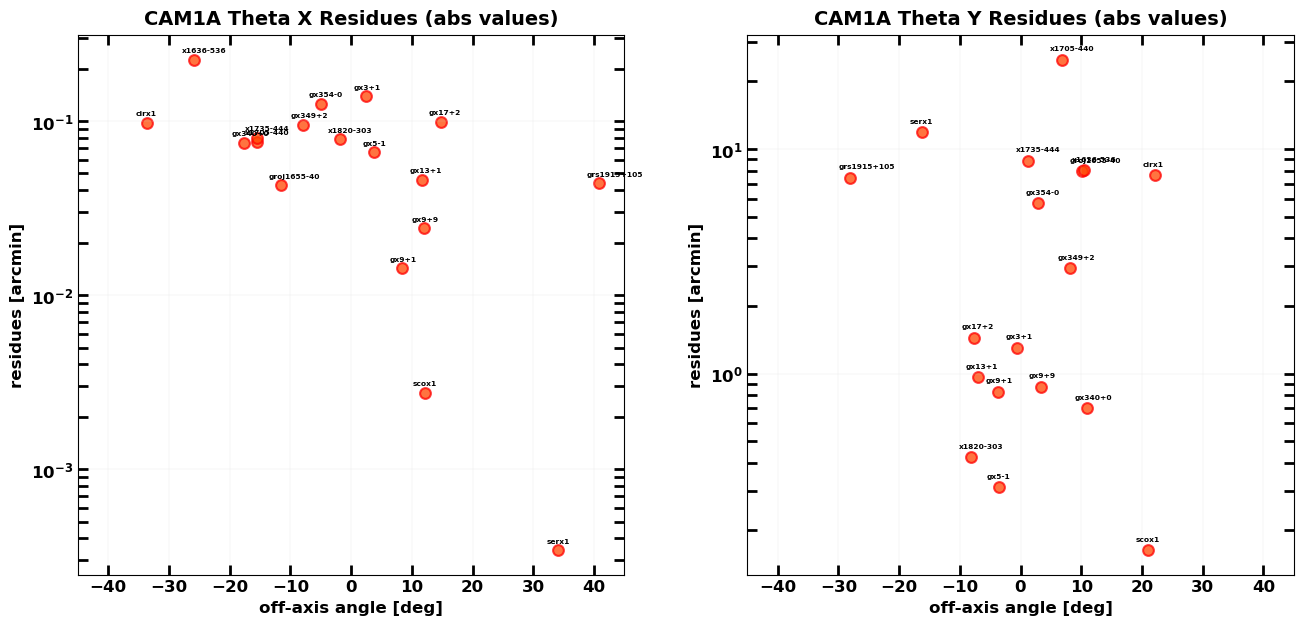

18 18


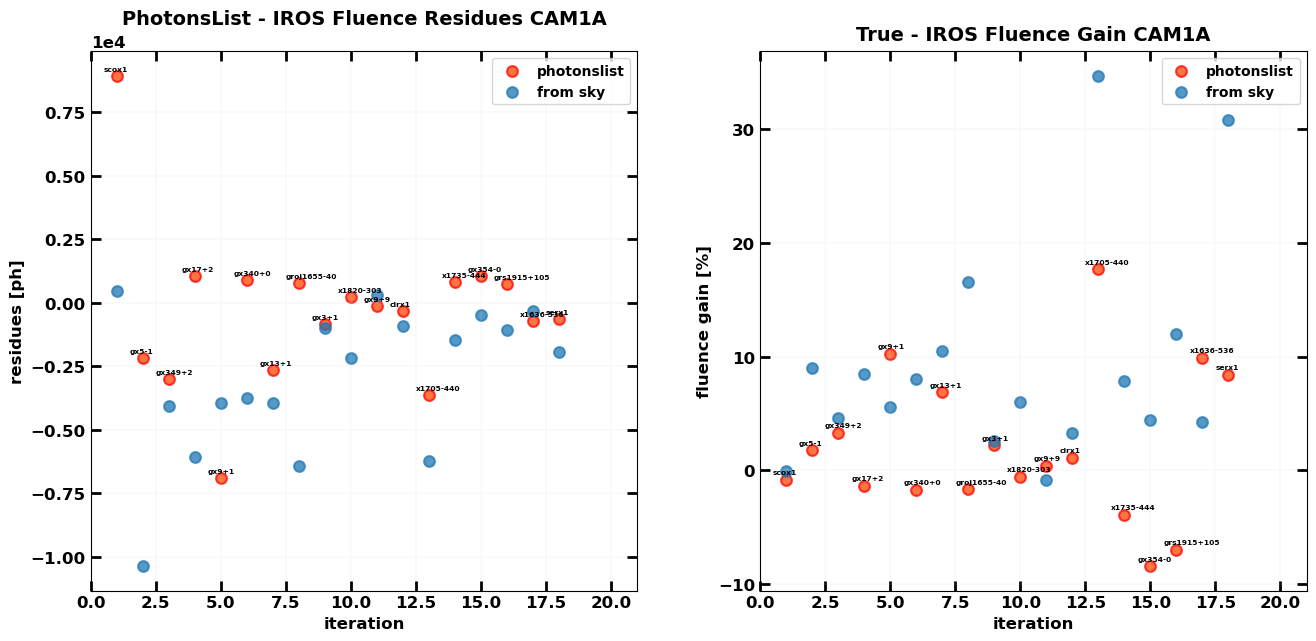

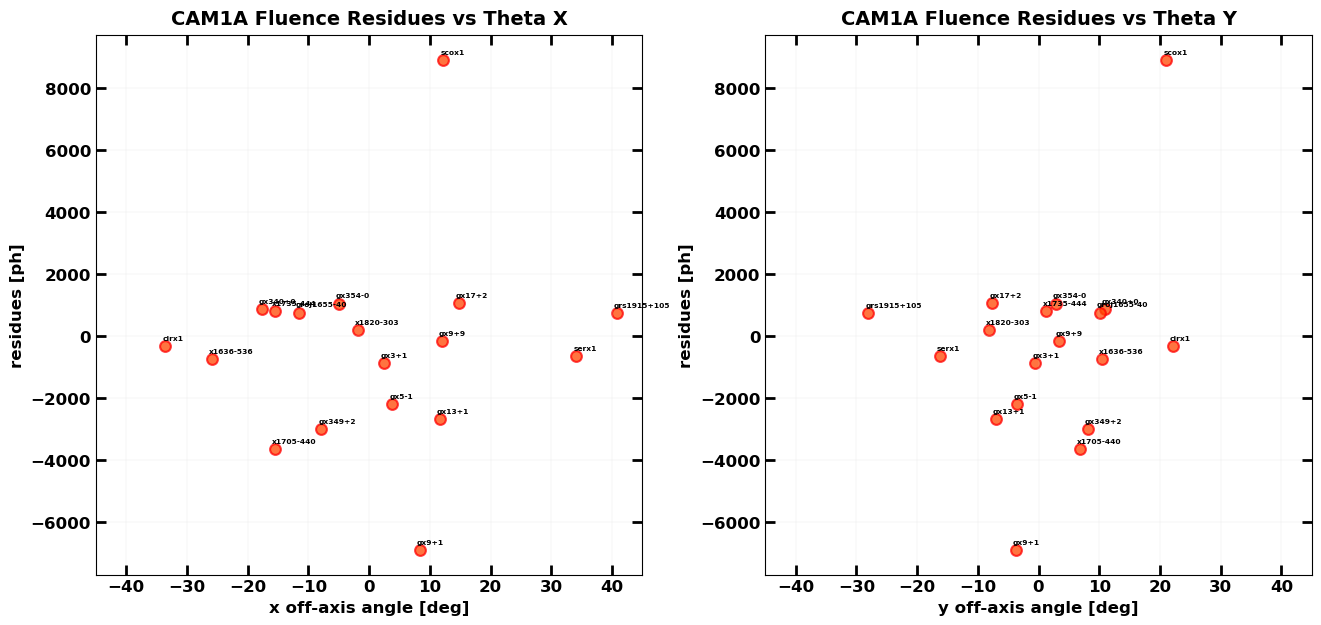

In [7]:
plot_thetas_residues(
    log=log_camA,
    sdl=sdlA,
    catalogue=catalogueA,
    camera=wfm,
)
plot_fluences_residues(
    log=log_camA,
    sdl=sdlA,
    catalogue=catalogueA,
    true_sky=simul_sky_camA,
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
plot_fluence_residues_vs_theta(
    log=log_camA,
    sdl=sdlA,
    catalogue=catalogueA,
    camera=wfm,
)

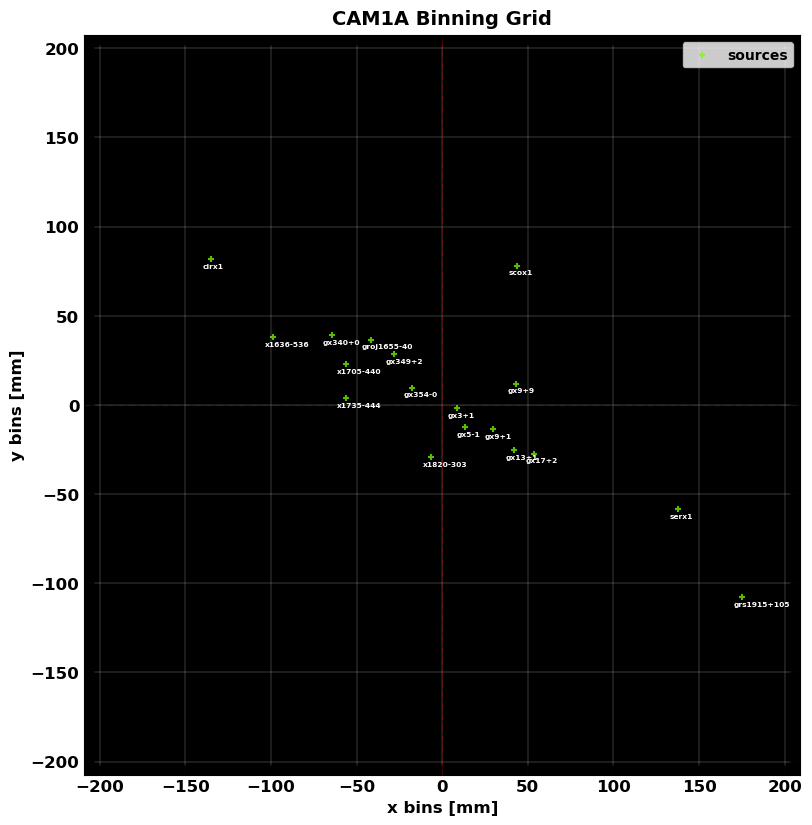

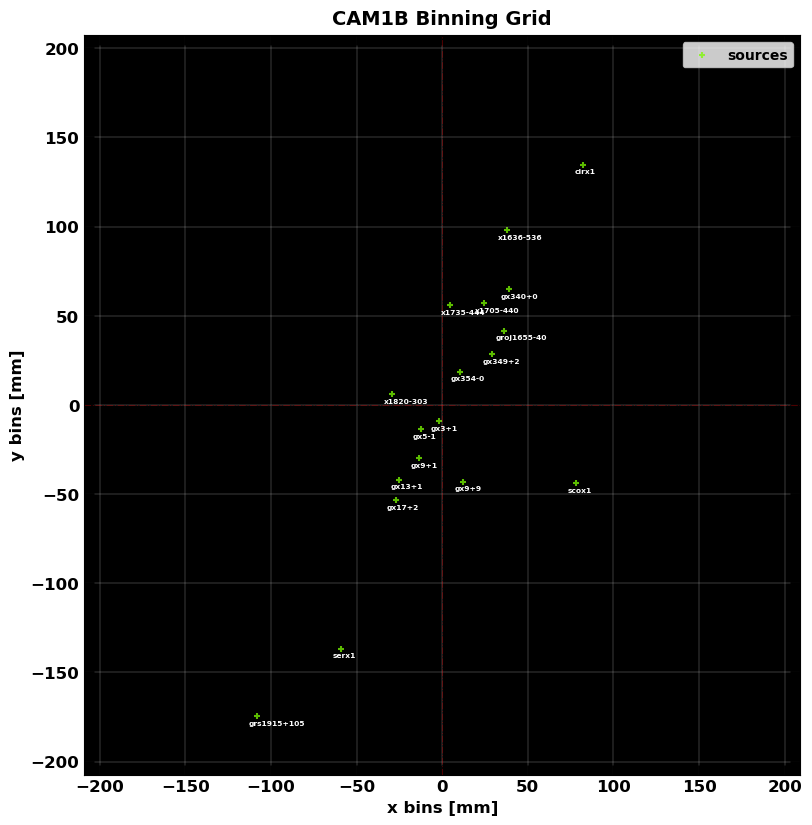

In [8]:
import matplotlib.patches as patches

def show_skyfield(
    log: Log,
    camera: CodedMaskCamera,
) -> None:
    """Plots the sky binning structure and the specified sources."""
    skyx, skyy = camera.bins_sky

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    fig.tight_layout()
    ax.add_patch(patches.Rectangle((skyx[0], skyy[0]), skyx[-1] - skyx[0], skyy[-1] - skyy[0], linewidth=1, edgecolor='k', facecolor='k'))
    ax.plot((skyx[0], skyx[-1]), (0, 0), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
    ax.plot((0, 0), (skyy[0], skyy[-1]), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
    ax.scatter(log.log["shift_x"], log.log["shift_y"], color="LawnGreen", marker="+", alpha=0.75, s=15, label="sources")

    for name, shiftx, shifty, ra, dec in zip(
        log.log['ID'],
        log.log['shift_x'],
        log.log['shift_y'],
        log.log['ra'],
        log.log['dec'],
    ):
        #ax.text(
        #    shiftx - 18, shifty + 5, f"RA: {ra:.4f}\nDEC: {dec:.4f}", color='white',
        #    fontsize=PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
        #)
        ax.text(
            shiftx - 5, shifty - 5, name, color='white',
            fontsize=0.9*PCAM["sourcename_fs"], fontweight=PCAM["txt_fw"],
        )
        #ax.add_patch(
        #    patches.Rectangle(
        #        (skyx[0], skyy[0]), skyx[-1] - skyx[0], skyy[-1] - skyy[0],
        #        linewidth=1, edgecolor='OrangeRed', facecolor=None,
        #    )
        #)

    plt.xlim((skyx[0], skyx[-1]))
    plt.ylim((skyy[0], skyy[-1]))
    ax.set_xlabel("x bins [mm]", fontsize=12, fontweight='bold')
    ax.set_ylabel("y bins [mm]", fontsize=12, fontweight='bold')
    ax.set_title(f"{log.name} Binning Grid", fontsize=14, pad=8, fontweight='bold')
    ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2)
    ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.legend(loc='best')
    plt.show()


show_skyfield(log=log_camA, camera=wfm)
show_skyfield(log=log_camB, camera=wfm)

In [9]:
assert False

cropx, cropy = (
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
)
plot_IROS_efficiency(
    log=log_camA,
    true_sky=simul_sky_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

AssertionError: 

In [ ]:
assert False

from IROS._pipeline_support import _handle_dirpaths
from bloodmoon.mask import codedmask
from bloodmoon.io import simulation_files
import darksun as ds

mask_FITS = "wfm_mask.fits"
#skyfield = "GalacticCenter"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"

skyfield = "IROSDummy"
data_FITS = "catalog_withCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "test_association_dsxdsy_same"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])

log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

_ = ds.compute_parameters(
    log=log_camA,
    camera=wfm,
    sdl=sdlA,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

AssertionError: 

In [ ]:
assert False


from IROS._pipeline_support import _handle_dirpaths
from IROS.singleCAM_iros import run_IROS

import numpy as np

from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

from darksun.data import get_data, get_catalogue




mask_FITS = "wfm_mask.fits"
skyfield = "IROSDummy"
data_FITS = "catalog_withCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = 'cam1a'
dataset = 'detected'
filepaths = simulation_files(simul_data)

s0 = CoordEquatorial(ra=223.438453172364, dec=-22.0306369561417)
s1 = CoordEquatorial(ra=231.465619039524, dec=-24.3850523670622)
s2 = CoordEquatorial(ra=241.426574413659, dec=-26.6219960573764)
s3 = CoordEquatorial(ra=253.284954989872, dec=-28.3032728404397)
s4 = CoordEquatorial(ra=266.4, dec=-28.94)
s5 = CoordEquatorial(ra=266.4, dec=-17.3775096005863)
s6 = CoordEquatorial(ra=266.4, dec=-6.63642699386322)
s7 = CoordEquatorial(ra=266.4, dec=2.68547284486862)
s8 = CoordEquatorial(ra=266.4, dec=10.4607609542733)
coords = (
    s0, s1, s2, s3, s5, s6, s7, s8,
)

sdlA = get_data(filepaths[cam_a][dataset], coords=coords)
catalogueA = get_catalogue(filepaths[cam_a]["sources"])


MAX_ITERATIONS = 1
SNR_THRESHOLD = 10
SKY_START = None

db, residual = run_IROS(
    camera=wfm,
    sdl=sdlA,
    max_iterations=MAX_ITERATIONS,
    snr_threshold=SNR_THRESHOLD,
    vignetting=VIGNETTING,
    psfy=PSFY,
    sky_start=SKY_START,
)

db

AssertionError: 